In [6]:
import os
import pandas as pd
import subprocess

# Path to the perturbation summary CSV
summary_csv_path = (
    "../../pnet_germline/processed/perturbed_genotype_datasets/p1000_somatic_mut/perturbation_summary.csv"
)

# Load the perturbation summary CSV
summary_df = pd.read_csv(summary_csv_path)
display(summary_df)
# Filter the rows based on the desired conditions
filtered_df = summary_df[
    (summary_df["fraction_samples"] == 0.5)
    & (summary_df["perturb_strength"] == 1.0)
    & (summary_df["n_features"].isin(["10", "100"]))
]
display(filtered_df)

# Define the perturbed data directory
perturbed_data_dir = "../../pnet_germline/processed/perturbed_genotype_datasets/p1000_somatic_mut"

# Define other parameters for the PNET model
data_config_f = "data.yaml"
evaluation_set = "validation"
model_type = "pnet"
wandb_project = "prostate_met_status"
wandb_group = "pnet_perturbed_data"
seed = 42
cpus = 8
input_data_dir = "../../pnet_germline/processed/wandb-group-data_prep_germline_tier12_and_somatic/converted-IDs-to-somatic_imputed-germline_True_imputed-somatic_False_paired-samples-True/wandb-run-id-q151d0zw"

# Iterate over the filtered rows and run the PNET model
for _, row in filtered_df.iterrows():
    perturbed_somatic_mut = os.path.basename(row["out_data_file"])  # Get the filename of the perturbed somatic_mut
    perturbed_target = os.path.basename(row["out_target_file"])  # Get the filename of the perturbed target

    # Construct the command to run the PNET model
    command = [
        "python",
        "run_model_on_perturbed_data.py",
        "--data_config_f",
        data_config_f,
        "--datasets",
        "somatic_amp somatic_del somatic_mut",
        "--evaluation_set",
        evaluation_set,
        "--model_type",
        model_type,
        "--wandb_project",
        wandb_project,
        "--wandb_group",
        wandb_group,
        "--seed",
        str(seed),
        "--input_data_dir",
        input_data_dir,
        "--perturbed_data_dir",
        perturbed_data_dir,
        "--perturbed_somatic_mut",
        perturbed_somatic_mut,
        "--perturbed_target",
        perturbed_target,
        "--cpus",
        str(cpus),
    ]

    # Print the command for debugging
    print(f"Running command: {' '.join(command)}")

    # Run the command
    subprocess.run(command)


,out_data_file,out_target_file,fraction_samples,n_features,perturb_strength,n_samples_affected,n_genes_perturbed
0,../../pnet_germline/processed/perturbed_genoty...,../../pnet_germline/processed/perturbed_genoty...,0.3,1,0.1,282,1
1,../../pnet_germline/processed/perturbed_genoty...,../../pnet_germline/processed/perturbed_genoty...,0.3,1,0.5,282,1
2,../../pnet_germline/processed/perturbed_genoty...,../../pnet_germline/processed/perturbed_genoty...,0.3,1,1.0,282,1
3,../../pnet_germline/processed/perturbed_genoty...,../../pnet_germline/processed/perturbed_genoty...,0.3,10,0.1,282,10
4,../../pnet_germline/processed/perturbed_genoty...,../../pnet_germline/processed/perturbed_genoty...,0.3,10,0.5,282,10
5,../../pnet_germline/processed/perturbed_genoty...,../../pnet_germline/processed/perturbed_genoty...,0.3,10,1.0,282,10
6,../../pnet_germline/processed/perturbed_genoty...,../../pnet_germline/processed/perturbed_genoty...,0.3,100,0.1,282,100
7,../../pnet_germline/processed/perturbed_genoty...,../../pnet_germline/processed/perturbed_genoty...,0.3,100,0.5,282,100
8,../../pnet_germline/processed/perturbed_genoty...,../../pnet_germline/processed/perturbed_genoty...,0.3,100,1.0,282,100
9,../../pnet_germline/processed/perturbed_genoty...,../../pnet_germline/processed/perturbed_genoty...,0.3,all,0.1,282,4854


,out_data_file,out_target_file,fraction_samples,n_features,perturb_strength,n_samples_affected,n_genes_perturbed
17,../../pnet_germline/processed/perturbed_genoty...,../../pnet_germline/processed/perturbed_genoty...,0.5,10,1.0,471,10
20,../../pnet_germline/processed/perturbed_genoty...,../../pnet_germline/processed/perturbed_genoty...,0.5,100,1.0,471,100


Running command: python run_model_on_perturbed_data.py --data_config_f data.yaml --datasets somatic_amp somatic_del somatic_mut --evaluation_set validation --model_type pnet --wandb_project prostate_met_status --wandb_group pnet_perturbed_data --seed 42 --input_data_dir ../../pnet_germline/processed/wandb-group-data_prep_germline_tier12_and_somatic/converted-IDs-to-somatic_imputed-germline_True_imputed-somatic_False_paired-samples-True/wandb-run-id-q151d0zw --perturbed_data_dir ../../pnet_germline/processed/perturbed_genotype_datasets/p1000_somatic_mut --perturbed_somatic_mut somatic_mut_samplePrcnt50_features10_strengthPrcnt100.csv --perturbed_target y_samplePrcnt50_features10_strengthPrcnt100.csv --cpus 8


wandb: Currently logged in as: millergw. Use `wandb login --relogin` to force relogin


Problem at: /mnt/disks/gmiller_data1/pnet/src/run_model_on_perturbed_data.py 120 main


wandb: ERROR You provided an invalid value for the `resume` argument. The value 'must' is not a valid option for resuming a run (2euaxr19) that does not exist. Please check your inputs and try again with a valid run ID. If you are trying to start a new run, please omit the `resume` argument or use `resume='allow'`.
Traceback (most recent call last):
  File "/mnt/disks/gmiller_data1/pnet/src/run_model_on_perturbed_data.py", line 331, in <module>
    main()
  File "/mnt/disks/gmiller_data1/pnet/src/run_model_on_perturbed_data.py", line 120, in main
    run = wandb.init(
  File "/opt/conda/envs/pnet/lib/python3.9/site-packages/wandb/sdk/wandb_init.py", line 1169, in init
    raise e
  File "/opt/conda/envs/pnet/lib/python3.9/site-packages/wandb/sdk/wandb_init.py", line 1150, in init
    run = wi.init()
  File "/opt/conda/envs/pnet/lib/python3.9/site-packages/wandb/sdk/wandb_init.py", line 769, in init
    raise error
wandb.errors.UsageError: You provided an invalid value for the `resume` 

KeyboardInterrupt: 

In [3]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [22]:
summary_df = pd.read_csv("../../pnet_germline/processed/perturbed_genotype_datasets/p1000_somatic_mut/perturbation_summary.csv")
summary_df


,out_data_file,out_target_file,fraction_samples,n_features,perturb_strength,n_samples_affected,n_genes_perturbed
0,../../pnet_germline/processed/perturbed_genoty...,../../pnet_germline/processed/perturbed_genoty...,0.3,1,0.1,282,1
1,../../pnet_germline/processed/perturbed_genoty...,../../pnet_germline/processed/perturbed_genoty...,0.3,1,0.5,282,1
2,../../pnet_germline/processed/perturbed_genoty...,../../pnet_germline/processed/perturbed_genoty...,0.3,1,1.0,282,1
3,../../pnet_germline/processed/perturbed_genoty...,../../pnet_germline/processed/perturbed_genoty...,0.3,10,0.1,282,10
4,../../pnet_germline/processed/perturbed_genoty...,../../pnet_germline/processed/perturbed_genoty...,0.3,10,0.5,282,10
5,../../pnet_germline/processed/perturbed_genoty...,../../pnet_germline/processed/perturbed_genoty...,0.3,10,1.0,282,10
6,../../pnet_germline/processed/perturbed_genoty...,../../pnet_germline/processed/perturbed_genoty...,0.3,100,0.1,282,100
7,../../pnet_germline/processed/perturbed_genoty...,../../pnet_germline/processed/perturbed_genoty...,0.3,100,0.5,282,100
8,../../pnet_germline/processed/perturbed_genoty...,../../pnet_germline/processed/perturbed_genoty...,0.3,100,1.0,282,100
9,../../pnet_germline/processed/perturbed_genoty...,../../pnet_germline/processed/perturbed_genoty...,0.3,all,0.1,282,4854


In [15]:
import pandas as pd
import numpy as np

# === Synthetic Data === #
# Create a small DataFrame to simulate the genotype matrix
np.random.seed(42)  # Set seed for reproducibility
samples = [f"Sample_{i}" for i in range(10)]  # 10 sample names
genes = [f"Gene_{j}" for j in range(5)]  # 5 gene names
data = np.random.randint(0, 2, size=(10, 5))  # Random binary data
df = pd.DataFrame(data, index=samples, columns=genes)

# Parameters
n_samples = len(samples)
frac_sample = 0.5  # 50% of samples
sample_subset = np.random.choice(range(n_samples), size=int(n_samples * frac_sample), replace=False)

# === Generate Target DataFrame === #
# Create a DataFrame with the same index as df
target = pd.DataFrame({"Tumor_Sample_Barcode": df.index})

# Populate the "is_met" column with 1 if the numeric index is in sample_subset, otherwise 0
target["is_met"] = target.index.map(lambda x: 1 if x in sample_subset else 0)

# Output for testing
print("Original DataFrame (df):")
print(df)
print("\nSample Subset (numeric indices):", sample_subset)
print("\nTarget DataFrame:")
print(target)

Original DataFrame (df):
          Gene_0  Gene_1  Gene_2  Gene_3  Gene_4
Sample_0       0       1       0       0       0
Sample_1       1       0       0       0       1
Sample_2       0       0       0       0       1
Sample_3       0       1       1       1       0
Sample_4       1       0       1       1       1
Sample_5       1       1       1       1       1
Sample_6       0       0       1       1       1
Sample_7       0       1       0       0       0
Sample_8       0       0       1       1       1
Sample_9       1       1       0       1       1

Sample Subset (numeric indices): [1 8 7 5 4]

Target DataFrame:
  Tumor_Sample_Barcode  is_met
0             Sample_0       0
1             Sample_1       1
2             Sample_2       0
3             Sample_3       0
4             Sample_4       1
5             Sample_5       1
6             Sample_6       0
7             Sample_7       1
8             Sample_8       1
9             Sample_9       0


array(['SAMPLE_9', 'SAMPLE_0', 'SAMPLE_12', 'SAMPLE_13', 'SAMPLE_6',
       'SAMPLE_14', 'SAMPLE_1', 'SAMPLE_4', 'SAMPLE_18', 'SAMPLE_11'],
      dtype=object)

,is_met
Tumor_Sample_Barcode,
SAMPLE_0,1
SAMPLE_1,1
SAMPLE_2,0
SAMPLE_3,0
SAMPLE_4,1
SAMPLE_5,0
SAMPLE_6,1
SAMPLE_7,0
SAMPLE_8,0


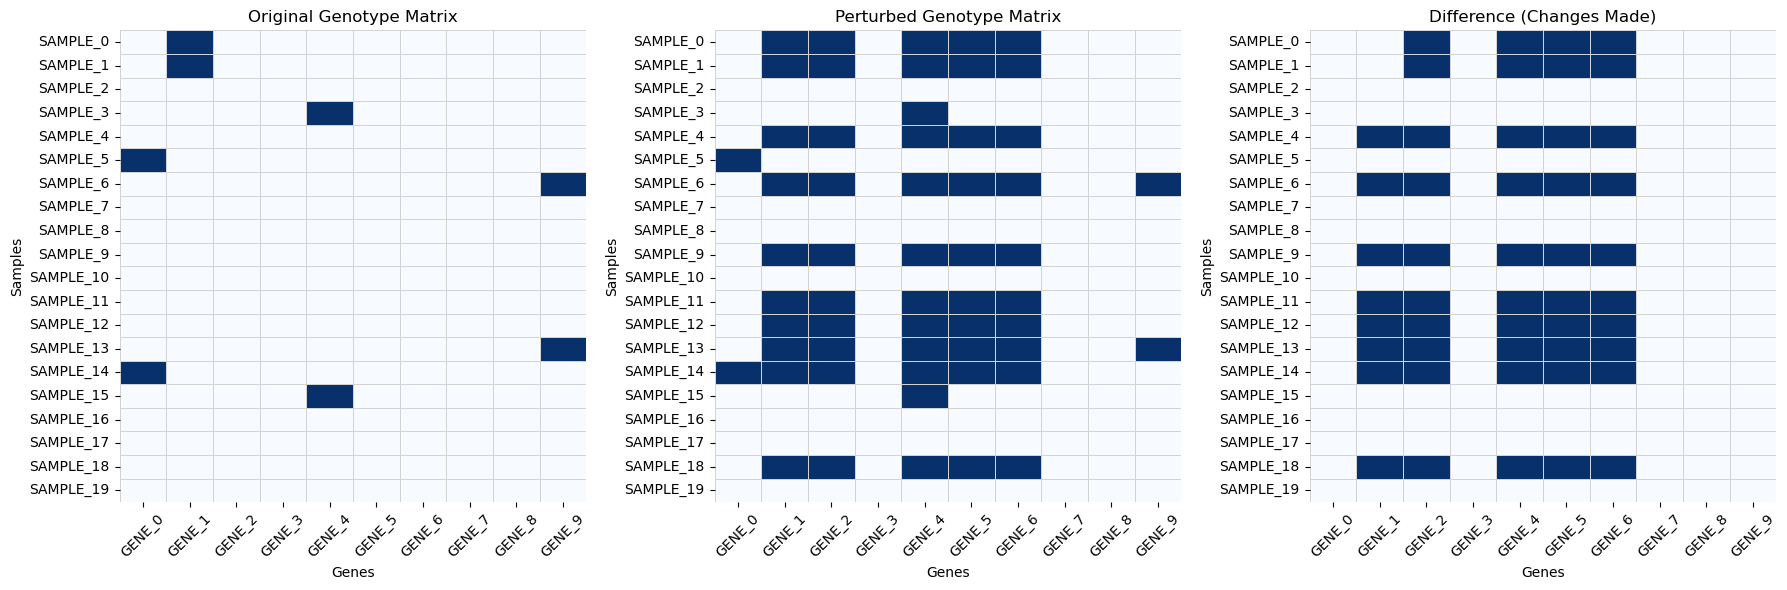


=== CHANGES ===
GENE_1: changed values in rows: ['SAMPLE_4', 'SAMPLE_6', 'SAMPLE_9', 'SAMPLE_11', 'SAMPLE_12', 'SAMPLE_13', 'SAMPLE_14', 'SAMPLE_18']
GENE_5: changed values in rows: ['SAMPLE_0', 'SAMPLE_1', 'SAMPLE_4', 'SAMPLE_6', 'SAMPLE_9', 'SAMPLE_11', 'SAMPLE_12', 'SAMPLE_13', 'SAMPLE_14', 'SAMPLE_18']
GENE_2: changed values in rows: ['SAMPLE_0', 'SAMPLE_1', 'SAMPLE_4', 'SAMPLE_6', 'SAMPLE_9', 'SAMPLE_11', 'SAMPLE_12', 'SAMPLE_13', 'SAMPLE_14', 'SAMPLE_18']
GENE_6: changed values in rows: ['SAMPLE_0', 'SAMPLE_1', 'SAMPLE_4', 'SAMPLE_6', 'SAMPLE_9', 'SAMPLE_11', 'SAMPLE_12', 'SAMPLE_13', 'SAMPLE_14', 'SAMPLE_18']
GENE_4: changed values in rows: ['SAMPLE_0', 'SAMPLE_1', 'SAMPLE_4', 'SAMPLE_6', 'SAMPLE_9', 'SAMPLE_11', 'SAMPLE_12', 'SAMPLE_13', 'SAMPLE_14', 'SAMPLE_18']


In [20]:
# === Set seed for reproducibility === #
np.random.seed(42)

# === Create toy binary genotype data (mostly 0s) === #
n_samples = 20
n_genes = 10
sparsity = 0.05  # 5% 1s

# Generate mostly 0s with a few 1s randomly sprinkled in
binary_data = np.random.choice([0, 1], size=(n_samples, n_genes), p=[1 - sparsity, sparsity])
gene_names = [f"GENE_{i}" for i in range(n_genes)]
sample_ids = [f"SAMPLE_{i}" for i in range(n_samples)]

df = pd.DataFrame(binary_data, index=sample_ids, columns=gene_names)

# === Perturbation settings === #
fraction_of_samples_affected = 0.5
number_of_genes_to_perturb = 5
perturbation_strength = 1

df_perturbed = df.copy()

# Step 1: choose subset of samples
sample_subset = np.random.choice(df.index, size=int(n_samples * fraction_of_samples_affected), replace=False)
display(sample_subset)
# Create a DataFrame with the same index as df_copy
target = pd.DataFrame({"Tumor_Sample_Barcode": df.index}).set_index("Tumor_Sample_Barcode")

# Populate the "is_met" column with 1 if the numeric index is in sample_subset, otherwise 0
target["is_met"] = target.index.map(lambda x: 1 if x in sample_subset else 0)
display(target)

# Step 2: choose subset of genes
selected_genes = np.random.choice(df.columns, size=number_of_genes_to_perturb, replace=False)

# Step 3: apply perturbation
for gene in selected_genes:
    rows_to_perturb = np.random.choice(
        sample_subset,
        size=max(1, int(len(sample_subset) * perturbation_strength)),
        replace=False,
    )
    df_perturbed.loc[rows_to_perturb, gene] = 1

# === Visualization === #
def plot_heatmap(data, title, ax):
    sns.heatmap(data, cmap="Blues", cbar=False, linewidths=0.5, linecolor='lightgray', ax=ax)
    ax.set_title(title)
    ax.set_xlabel("Genes")
    ax.set_ylabel("Samples")
    ax.set_xticklabels(data.columns, rotation=45)
    ax.set_yticklabels(data.index, rotation=0)

# Difference matrix (shows only changes)
diff = df_perturbed != df
diff = diff.astype(int)

# === Plot original, perturbed, and difference === #
fig, axs = plt.subplots(1, 3, figsize=(18, 6))
plot_heatmap(df, "Original Genotype Matrix", axs[0])
plot_heatmap(df_perturbed, "Perturbed Genotype Matrix", axs[1])
plot_heatmap(diff, "Difference (Changes Made)", axs[2])
plt.tight_layout()
plt.show()

# === Console report of changes === #
print("\n=== CHANGES ===")
for gene in selected_genes:
    changed = df[gene] != df_perturbed[gene]
    changed_rows = df.index[changed]
    print(f"{gene}: changed values in rows: {list(changed_rows)}")


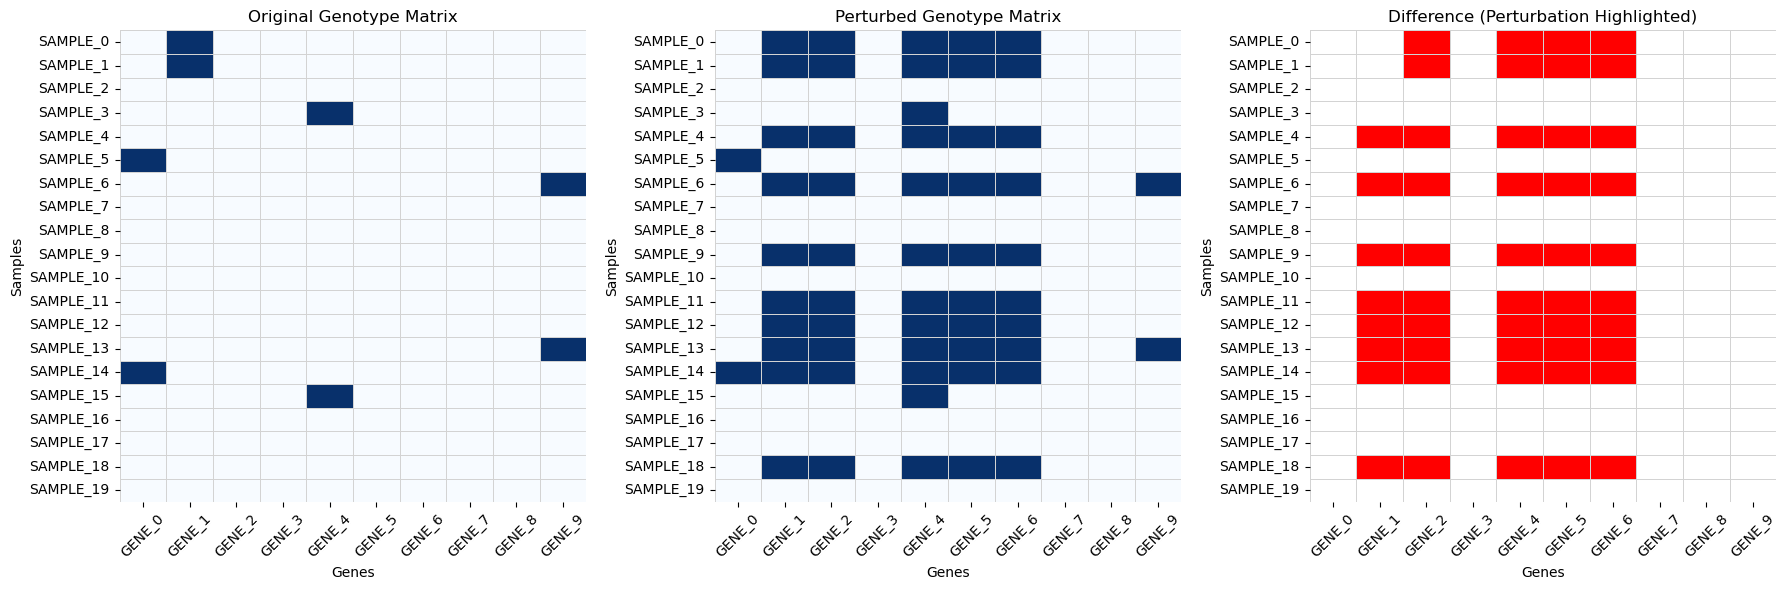

In [11]:
# === Visualization === #
def plot_heatmap(data, title, ax, cmap="Blues"):
    sns.heatmap(data, cmap=cmap, cbar=False, linewidths=0.5, linecolor='lightgray', ax=ax)
    ax.set_title(title)
    ax.set_xlabel("Genes")
    ax.set_ylabel("Samples")
    ax.set_xticklabels(data.columns, rotation=45)
    ax.set_yticklabels(data.index, rotation=0)

# Difference matrix: 1 where value changed, 0 otherwise
diff = (df_perturbed != df).astype(int)

# Custom red-white colormap for highlighting perturbed values
from matplotlib.colors import ListedColormap
red_cmap = ListedColormap(["white", "red"])

# === Plot original, perturbed, and difference === #
fig, axs = plt.subplots(1, 3, figsize=(18, 6))
plot_heatmap(df, "Original Genotype Matrix", axs[0], cmap="Blues")
plot_heatmap(df_perturbed, "Perturbed Genotype Matrix", axs[1], cmap="Blues")
plot_heatmap(diff, "Difference (Perturbation Highlighted)", axs[2], cmap=red_cmap)
plt.tight_layout()
plt.show()
